In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
file=pd.read_csv('Mall_Customers.csv')
file

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
file.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


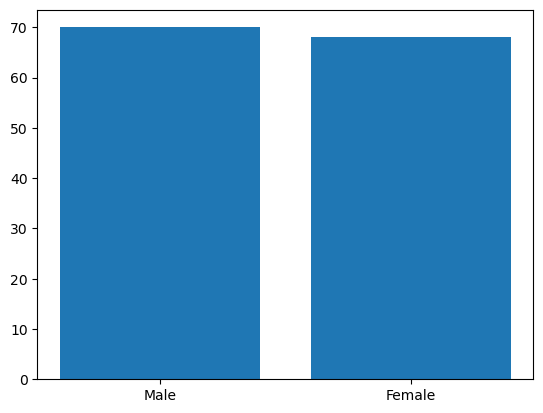

In [4]:
plt.bar(file["Gender"],file["Age"])
plt.show()

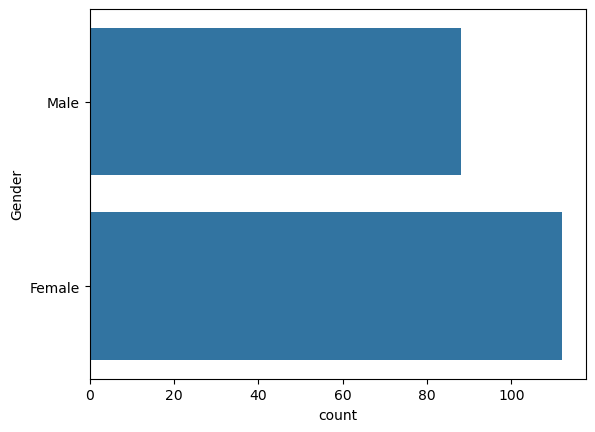

In [5]:

sns.countplot(file['Gender'])
plt.show()

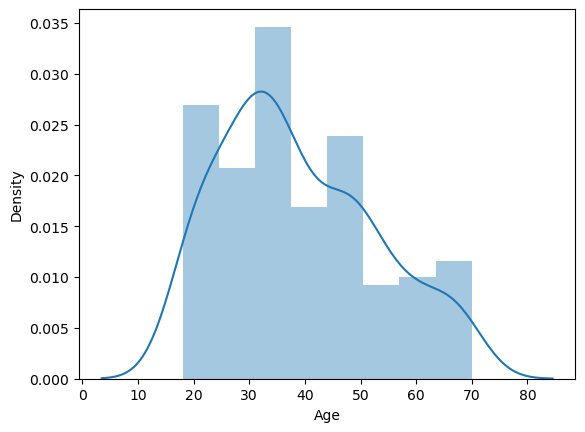

In [6]:
sns.distplot(file['Age'])
plt.show()

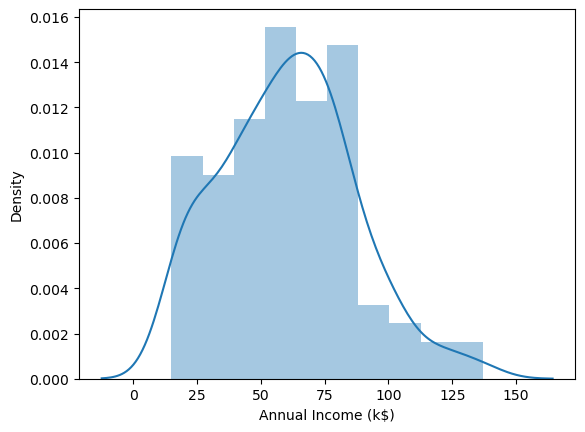

In [7]:
sns.distplot(file['Annual Income (k$)'])
plt.show()

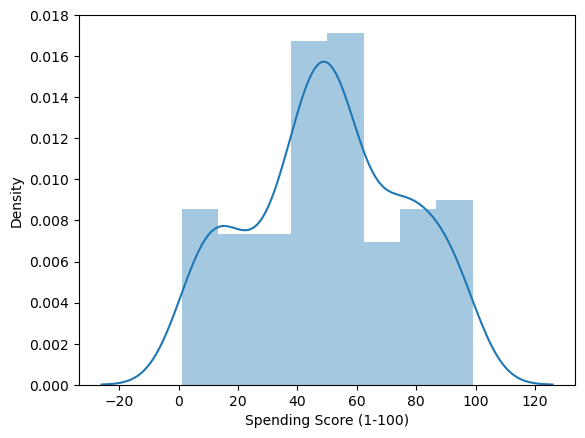

In [8]:
sns.distplot(file['Spending Score (1-100)'])
plt.show()

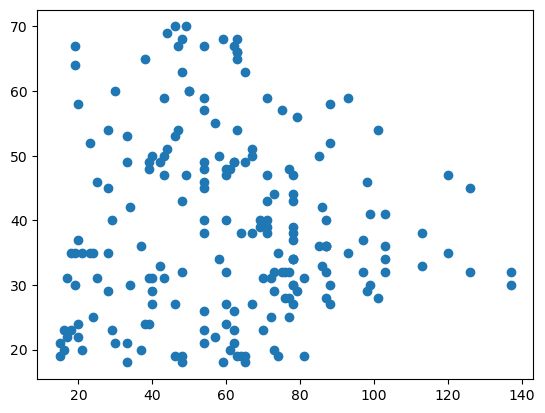

In [9]:
plt.scatter(file["Annual Income (k$)"],file["Age"])
plt.show()

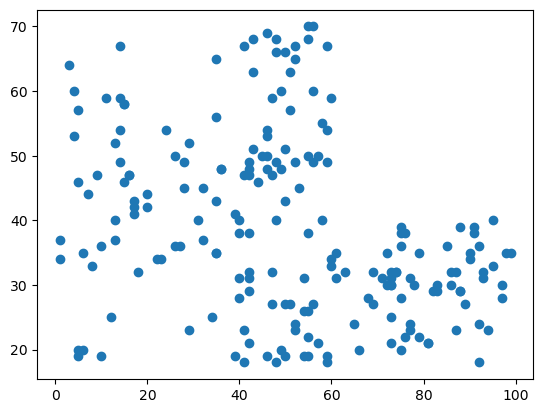

In [10]:
plt.scatter(file["Spending Score (1-100)"],file["Age"])
plt.show()

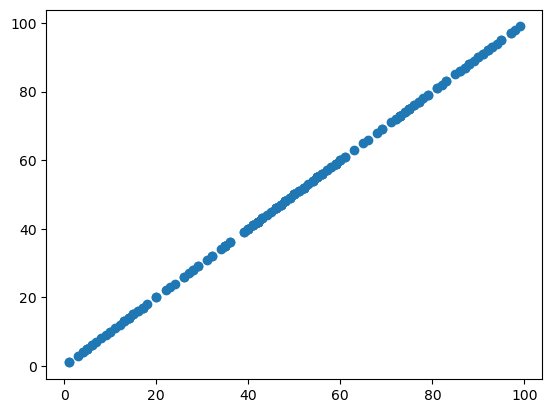

In [11]:
plt.scatter(file["Spending Score (1-100)"],file["Spending Score (1-100)"])
plt.show()

In [12]:
km=KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [13]:
y_predicted=km.fit_predict(file[["Spending Score (1-100)","Spending Score (1-100)"]])
y_predicted

array([0, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 0, 1,
       2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 0, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1])

In [14]:
file['cluster']=y_predicted
file.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,1
2,3,Female,20,16,6,2
3,4,Female,23,16,77,1
4,5,Female,31,17,40,0


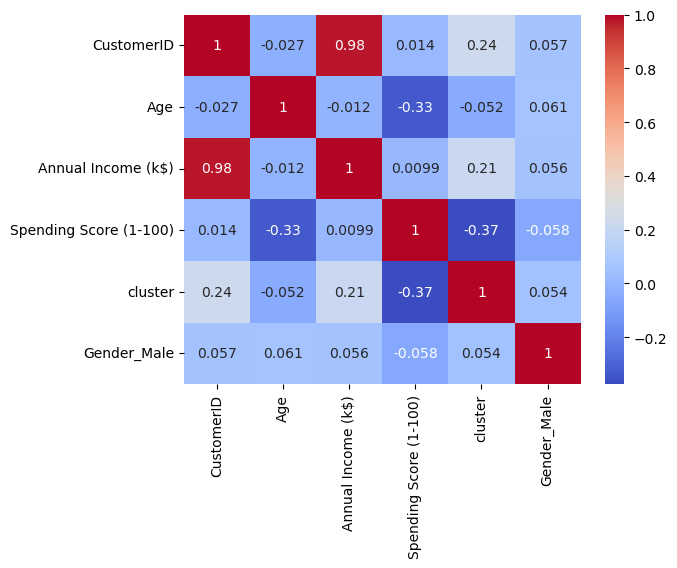

In [15]:
file_encoded = pd.get_dummies(file, drop_first=True)

corr = file_encoded.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


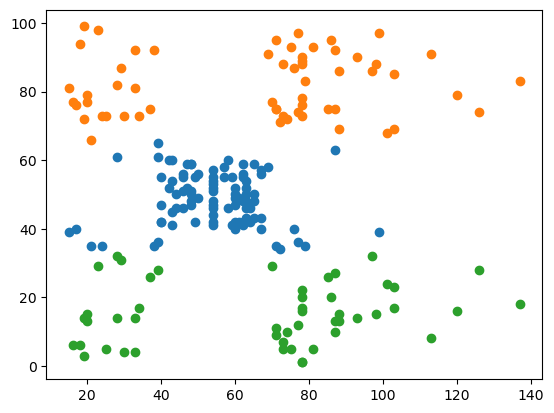

In [16]:
df1=file[file.cluster==0]
df2=file[file.cluster==1]
df3=file[file.cluster==2]
df4=file[file.cluster==3]
plt.scatter(df1['Annual Income (k$)'],df1['Spending Score (1-100)'])
plt.scatter(df2['Annual Income (k$)'],df2['Spending Score (1-100)'])
plt.scatter(df3['Annual Income (k$)'],df3['Spending Score (1-100)'])

plt.show()

In [18]:
df1=file[['Annual Income (k$)',	'Spending Score (1-100)']]

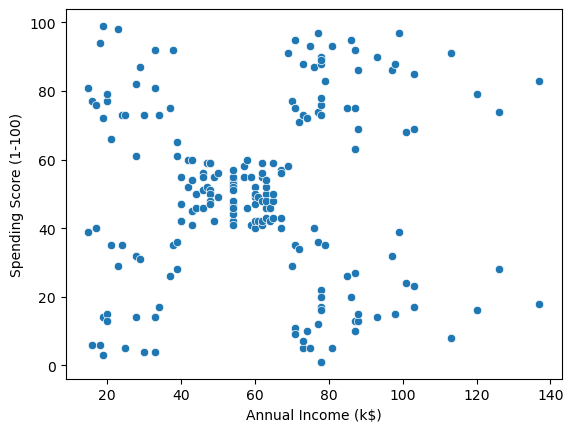

In [19]:
sns.scatterplot(
    x=df1['Annual Income (k$)'],
    y=df1['Spending Score (1-100)']
)
plt.show()


In [20]:
from sklearn.cluster import KMeans
errors=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(df1)
    errors.append(kmeans.inertia_)

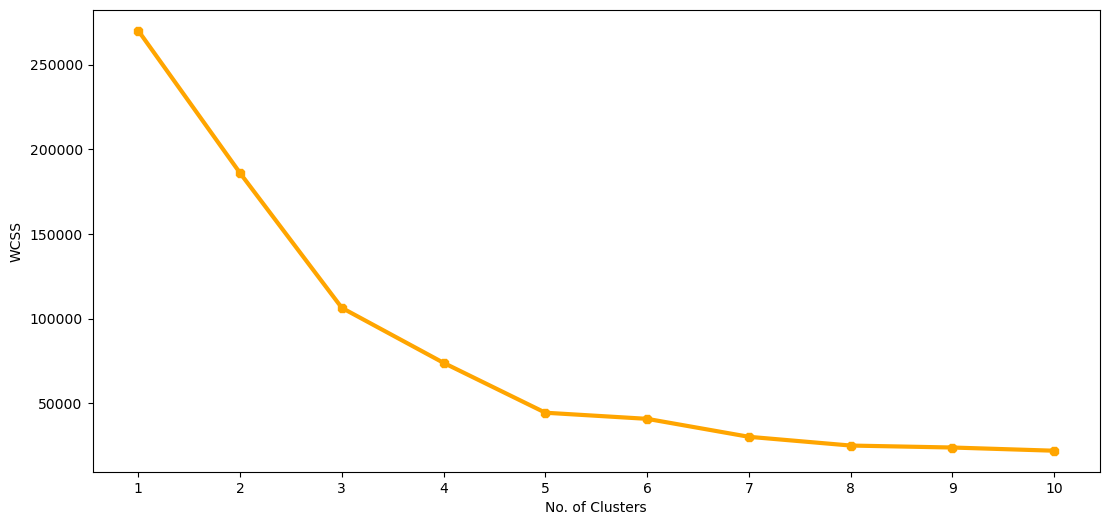

In [21]:
plt.figure(figsize=(13,6))
plt.plot(range(1,11),errors)
plt.plot(range(1,11),errors,linewidth=3,color='orange',marker='8')
plt.xticks(np.arange(1,11,1))
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")
plt.show()

In [22]:
km=KMeans(n_clusters=5)
km.fit(df1)
y=km.predict(df1)
df1['label']=y
df1.head()

,Annual Income (k$),Spending Score (1-100),label
0,15,39,0
1,15,81,3
2,16,6,0
3,16,77,3
4,17,40,0


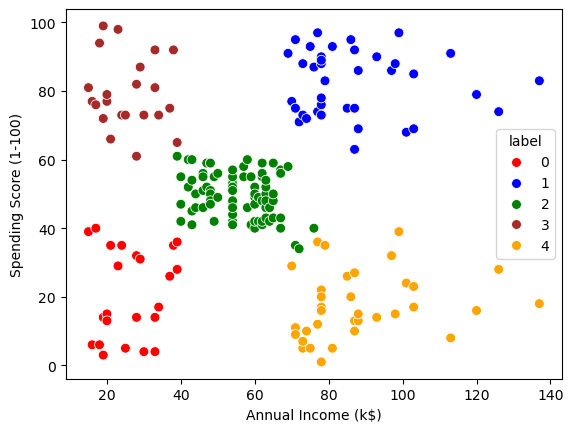

In [23]:
sns.scatterplot(x="Annual Income (k$)",y="Spending Score (1-100)",data=df1,hue="label",s=50,palette=['red','blue','green','brown','orange'])
plt.show()